# Q-Learning Homework (FrozenLake)

Full implementation with explanations and epsilon decay.

# Exercise 1: Conceptual Answers

## Learning Rate (alpha)
- alpha = 0 → no learning (Q-table never updates)
- alpha = 1 → only newest experience matters

Alpha controls how much new information overrides old knowledge.

## Q-Table Initialization
Optimistic initialization encourages exploration because the agent assumes high rewards everywhere and tries more actions.

## TD vs Monte Carlo
TD (Q-learning):
- Updates after every step → faster learning
- Works well for long games

Monte Carlo:
- Updates only at end → slow and inefficient for long episodes


In [15]:
import gymnasium as gym
import numpy as np

env = gym.make('FrozenLake-v1', is_slippery=False)


In [16]:
state_size = env.observation_space.n
action_size = env.action_space.n

Q = np.zeros((state_size, action_size))

print("Q-table shape:", Q.shape)


Q-table shape: (16, 4)


In [17]:
alpha = 0.1
gamma = 0.99
episodes = 10000
epsilon = 0.1


In [18]:
for episode in range(episodes):
    reset_out = env.reset()
    state = reset_out[0] if isinstance(reset_out, tuple) else reset_out
    
    done = False
    
    while not done:
        if np.random.rand() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(Q[state])
        
        step_out = env.step(action)
        
        if len(step_out) == 5:
            new_state, reward, terminated, truncated, _ = step_out
            done = terminated or truncated
        else:
            new_state, reward, done, _ = step_out
        
        Q[state, action] += alpha * (
            reward + gamma * np.max(Q[new_state]) - Q[state, action]
        )
        
        state = new_state

In [19]:
# Epsilon decay version

Q_decay = np.zeros((state_size, action_size))

max_epsilon = 1.0
min_epsilon = 0.01
decay_rate = 0.001

rewards = []

for episode in range(episodes):
    state = env.reset()[0]
    done = False
    total_reward = 0
    
    epsilon = min_epsilon + (max_epsilon - min_epsilon) * np.exp(-decay_rate * episode)
    
    while not done:
        if np.random.rand() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(Q_decay[state])
        
        new_state, reward, done, _, _ = env.step(action)
        
        Q_decay[state, action] += alpha * (
            reward + gamma * np.max(Q_decay[new_state]) - Q_decay[state, action]
        )
        
        state = new_state
        total_reward += reward
    
    rewards.append(total_reward)

print("Q-table with decay:")
print(Q_decay)


Q-table with decay:
[[0.94148015 0.93206535 0.95099005 0.94148015]
 [0.94148015 0.         0.96059601 0.95099005]
 [0.95099005 0.970299   0.95099004 0.96059601]
 [0.96059601 0.         0.89539021 0.8838741 ]
 [0.91973528 0.85847834 0.         0.94148015]
 [0.         0.         0.         0.        ]
 [0.         0.9801     0.         0.96059601]
 [0.         0.         0.         0.        ]
 [0.3896416  0.         0.95468612 0.42515277]
 [0.68605951 0.7980517  0.9801     0.        ]
 [0.97029898 0.99       0.         0.97029884]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.74754817 0.98999991 0.59770621]
 [0.98009872 0.98999999 1.         0.98009998]
 [0.         0.         0.         0.        ]]


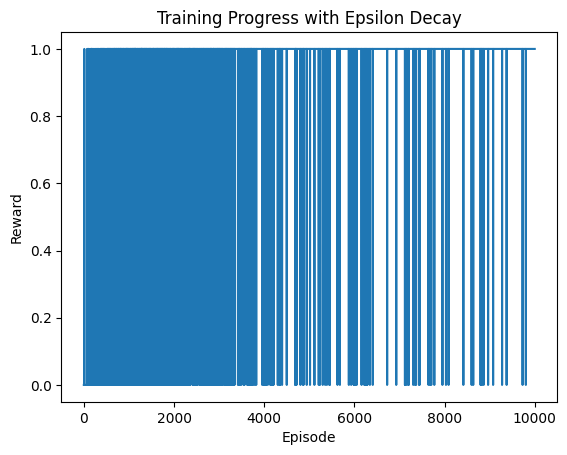

In [20]:
import matplotlib.pyplot as plt

plt.plot(rewards)
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Training Progress with Epsilon Decay")
plt.show()
